# Intensity Transformations & Filtering Spatial Domain

## Thresholding

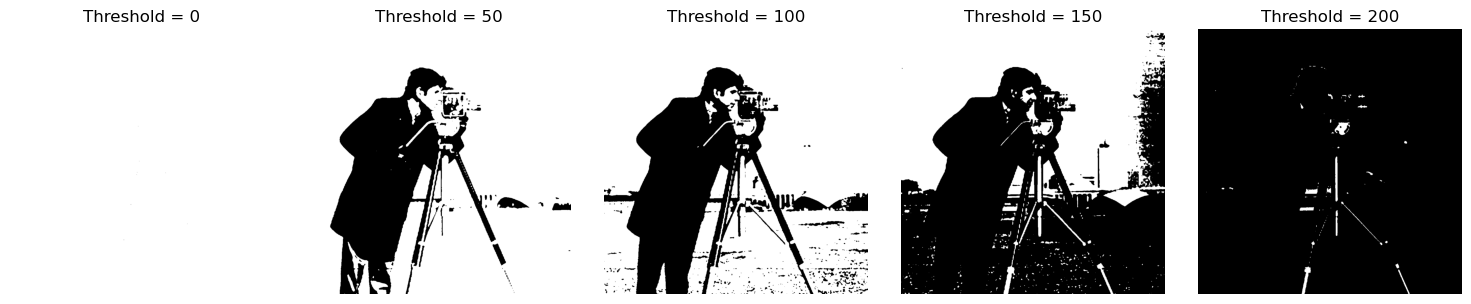

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the provided image in grayscale
img = cv2.imread(
    "cameraman.png",
    cv2.IMREAD_GRAYSCALE
)

if img is None:
    raise FileNotFoundError(
        "cameraman.png was not found. Place it beside the notebook."
    )

threshold_values = [0, 50, 100, 150, 200]

plt.figure(figsize=(15, 3))

for i, threshold_value in enumerate(threshold_values):
    ret_thresh_value, thresh_img = cv2.threshold(
        img,
        threshold_value,
        255,
        cv2.THRESH_BINARY
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(thresh_img, cmap="gray")
    plt.title(f"Threshold = {threshold_value}")
    plt.axis("off")

plt.tight_layout()
plt.show()

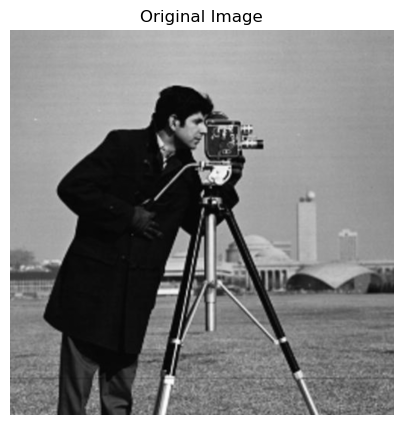

In [4]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

## Histograms

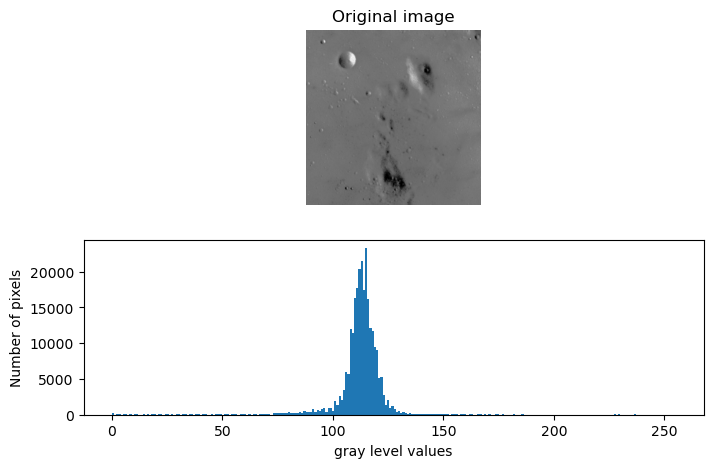

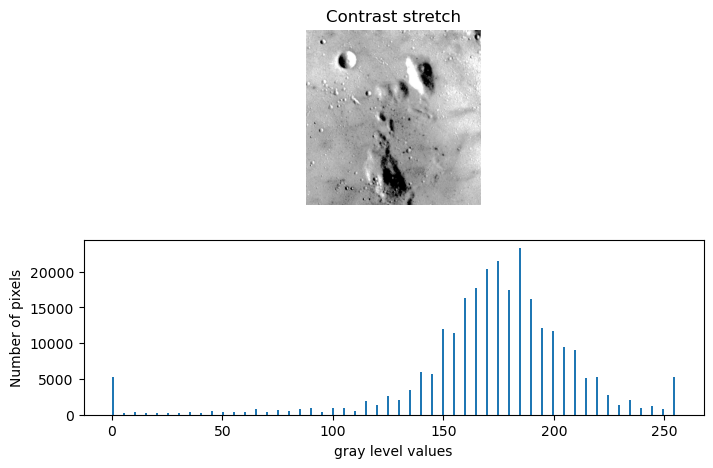

In [5]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


3rd percentile: 87.0
80th percentile: 118.0


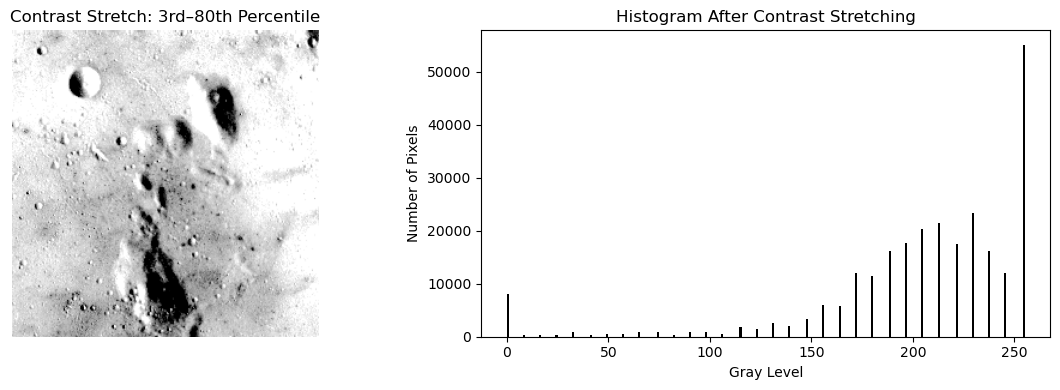

In [6]:
# Task 1: Contrast stretching using 3rd and 80th percentiles

moon_image = data.moon()

p3, p80 = np.percentile(moon_image, (3, 80))

moon_rescaled = exposure.rescale_intensity(
    moon_image,
    in_range=(p3, p80)
)

print("3rd percentile:", p3)
print("80th percentile:", p80)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(moon_rescaled, cmap="gray")
plt.title("Contrast Stretch: 3rd–80th Percentile")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.hist(
    moon_rescaled.ravel(),
    bins=256,
    range=(0, 255),
    color="black"
)
plt.title("Histogram After Contrast Stretching")
plt.xlabel("Gray Level")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

Rescaling the image using the 3rd and 80th percentiles expands the selected intensity range and improves the image contrast.

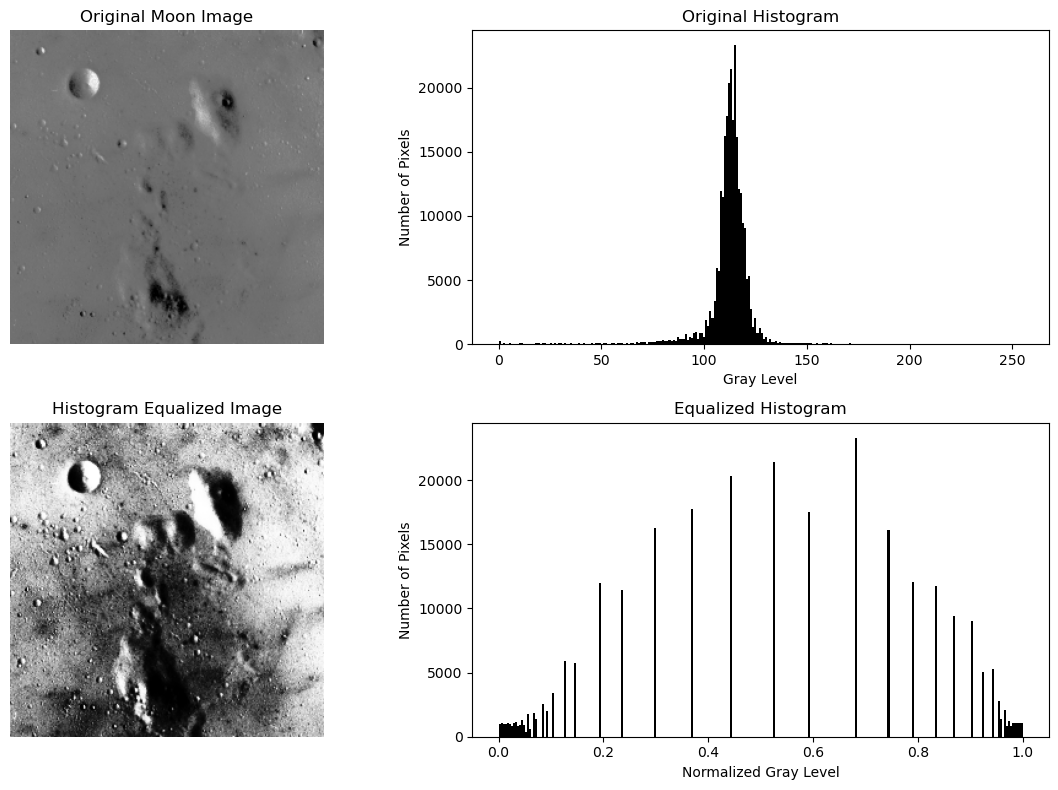

In [7]:
# Task 2: Histogram equalization

moon_equalized = exposure.equalize_hist(moon_image)

plt.figure(figsize=(12, 8))

# Original image
plt.subplot(2, 2, 1)
plt.imshow(moon_image, cmap="gray")
plt.title("Original Moon Image")
plt.axis("off")

# Original histogram
plt.subplot(2, 2, 2)
plt.hist(
    moon_image.ravel(),
    bins=256,
    range=(0, 255),
    color="black"
)
plt.title("Original Histogram")
plt.xlabel("Gray Level")
plt.ylabel("Number of Pixels")

# Equalized image
plt.subplot(2, 2, 3)
plt.imshow(moon_equalized, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")

# Equalized histogram
plt.subplot(2, 2, 4)
plt.hist(
    moon_equalized.ravel(),
    bins=256,
    range=(0, 1),
    color="black"
)
plt.title("Equalized Histogram")
plt.xlabel("Normalized Gray Level")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

Histogram equalization redistributes the intensity values over a wider range, producing a flatter histogram and enhancing the image contrast.

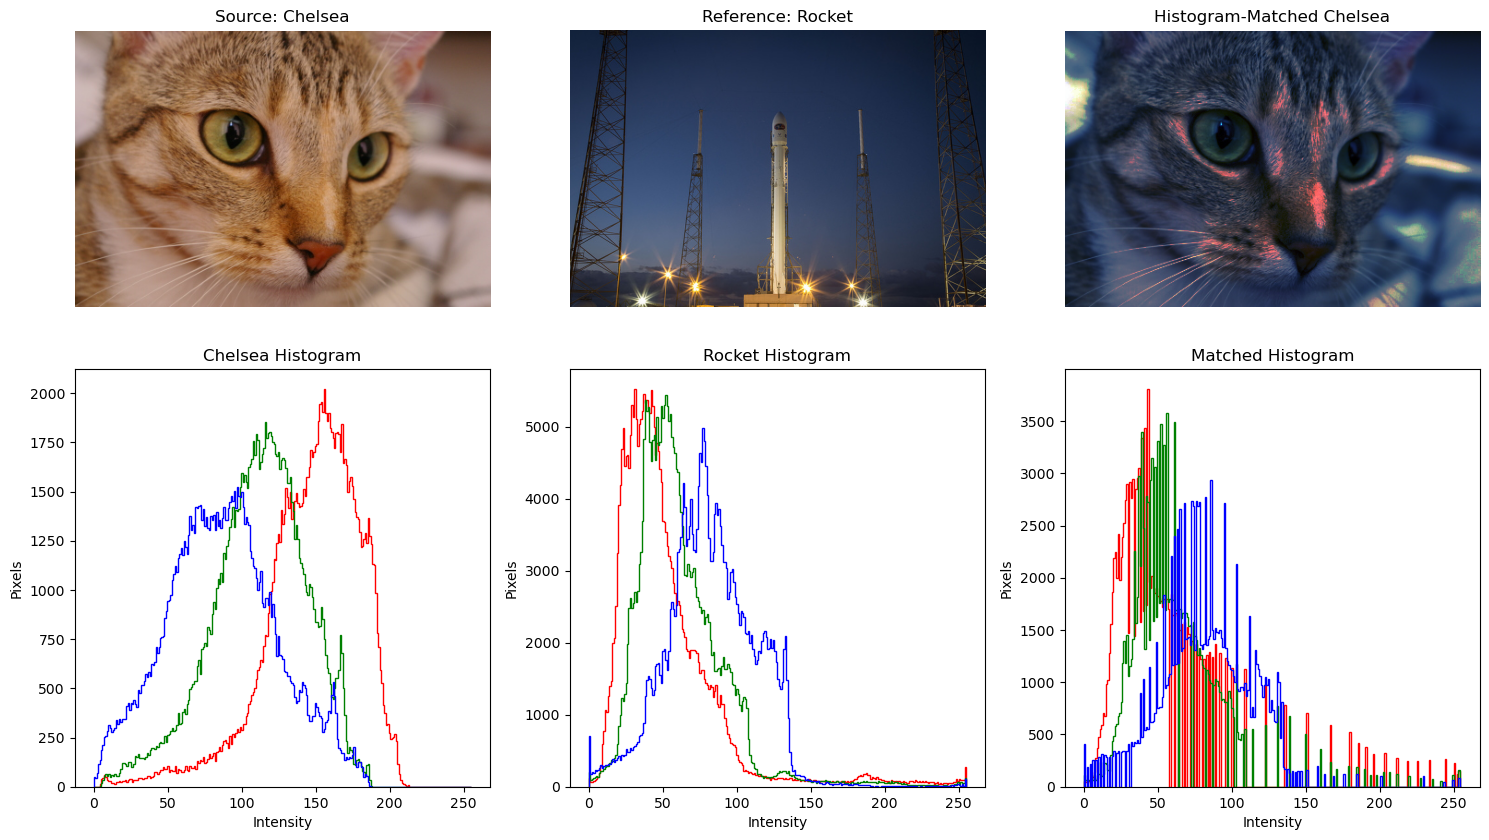

In [8]:
# Task 3: Histogram matching

source_image = data.chelsea()
reference_image = data.rocket()

matched_image = exposure.match_histograms(
    source_image,
    reference_image,
    channel_axis=-1
)

matched_image = np.clip(
    matched_image,
    0,
    255
).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Images
axes[0, 0].imshow(source_image)
axes[0, 0].set_title("Source: Chelsea")
axes[0, 0].axis("off")

axes[0, 1].imshow(reference_image)
axes[0, 1].set_title("Reference: Rocket")
axes[0, 1].axis("off")

axes[0, 2].imshow(matched_image)
axes[0, 2].set_title("Histogram-Matched Chelsea")
axes[0, 2].axis("off")

colors = ["red", "green", "blue"]

# Chelsea histogram
for channel, color in enumerate(colors):
    axes[1, 0].hist(
        source_image[:, :, channel].ravel(),
        bins=256,
        range=(0, 255),
        histtype="step",
        color=color
    )

axes[1, 0].set_title("Chelsea Histogram")
axes[1, 0].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Pixels")

# Rocket histogram
for channel, color in enumerate(colors):
    axes[1, 1].hist(
        reference_image[:, :, channel].ravel(),
        bins=256,
        range=(0, 255),
        histtype="step",
        color=color
    )

axes[1, 1].set_title("Rocket Histogram")
axes[1, 1].set_xlabel("Intensity")
axes[1, 1].set_ylabel("Pixels")

# Matched histogram
for channel, color in enumerate(colors):
    axes[1, 2].hist(
        matched_image[:, :, channel].ravel(),
        bins=256,
        range=(0, 255),
        histtype="step",
        color=color
    )

axes[1, 2].set_title("Matched Histogram")
axes[1, 2].set_xlabel("Intensity")
axes[1, 2].set_ylabel("Pixels")

plt.tight_layout()
plt.show()

Histogram matching changes the color distribution of the Chelsea image to resemble the Rocket reference image while preserving the content and structure of the Chelsea image.